# investigate IP utilization of anycast prefixes

## questions
* how many IPs are used in anycast deployments?
* are there ASes with high utilization?
* are there ASes with low utilization (DNS?)
* are there ASes with a mix of high and low utilization
* which prefixes are HRP?
* which ASes deploy HRP?

In [1]:
import pandas as pd
from pathlib import Path

import sys
analysis_dir = Path.cwd().parent
sys.path.append(str(analysis_dir))
from add_ASN import CaidaASLookup
import census_helper
from datetime import datetime

ts = datetime(2026, 2, 18)

import matplotlib.pyplot as plt

# configure matplotlib variables (font and size)
plt.style.use("default")

plt.rcParams["axes.labelsize"] = 20
plt.rcParams.update({'font.size': 14})


In [2]:
# load in census data

census_v4 = census_helper.download_date(ts, 'v4')
# filter on GCD-confirmed (high-confidence)
census_v4 = census_v4[census_v4['GCD_ICMPv4'] > 1]

census_v4

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations
0,1.0.0.0/24,29,29,29,79,7,False,1.0.0.0/24,13335,"[{'city': 'Honolulu', 'country_code': 'US', 'i..."
1,1.1.1.0/24,29,29,29,77,6,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
3,1.10.10.0/24,3,0,3,3,0,False,1.10.10.0/24,148000,"[{'city': 'Delhi', 'country_code': 'IN', 'id':..."
4,1.12.0.0/24,5,0,5,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Baltimore', 'country_code': 'US', '..."
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."
...,...,...,...,...,...,...,...,...,...,...
35229,99.83.255.0/24,26,0,0,59,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id..."
35230,99.84.1.0/24,2,0,0,2,0,False,99.84.1.0/24,16509,"[{'city': 'Madrid', 'country_code': 'ES', 'id'..."
35238,99.99.97.0/24,2,1,2,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'..."
35239,99.99.98.0/24,2,0,2,2,0,False,99.96.0.0/13,7018,"[{'city': 'Atlanta', 'country_code': 'US', 'id..."


In [3]:
census_v4['ASN'].str.split('_').explode().nunique()

1075

In [4]:
# load in HRP data

# hrp = pd.read_csv('nl-ens_20260204_slash24-info.csv.gz')
hrp = pd.read_csv('part-00000-221fd490-deca-4171-ad09-7cf2764b8c5b-c000.csv')
# hrp['/24'] = hrp['ip'].str.rsplit('.', n=1).str[0] + '.0/24'
hrp = hrp[hrp['is_hrp']]
hrp

,prefix,is_hrp
1,140.248.188.0/24,True
2,104.24.9.0/24,True
3,34.107.223.0/24,True
4,167.82.72.0/24,True
5,199.232.8.0/24,True
...,...,...
13771,167.82.116.0/24,True
13772,23.156.128.0/24,True
13773,146.75.102.0/24,True
13775,173.194.239.0/24,True


In [5]:
# join census with HRP

census_v4['is_hrp'] = census_v4['prefix'].isin(hrp['prefix'])

print(f"there are {census_v4['prefix'].nunique():,} /24s of which {census_v4[census_v4['is_hrp']]['prefix'].nunique():,} are HRP")

there are 14,346 /24s of which 9,713 are HRP


In [6]:
# load in IPs with services (excluding unknowns)

ip_services = pd.read_csv('part-00000-a6158df2-c124-48da-814d-c180043134fa-c000.csv')
ip_services

,ip,year,month,day
0,104.16.43.235,2026,2,18
1,104.17.133.209,2026,2,18
2,104.17.158.15,2026,2,18
3,104.17.73.122,2026,2,18
4,104.19.133.123,2026,2,18
...,...,...,...,...
1769798,34.160.10.83,2026,2,18
1769799,34.43.185.231,2026,2,18
1769800,34.54.161.156,2026,2,18
1769801,34.95.114.165,2026,2,18


In [7]:
ip_services['ip'].nunique()

1769803

In [8]:
ip_services['/24'] = (
    ip_services['ip']
        .str.split('.')
        .str[:3]
        .str.join('.') + '.0/24'
)

ip_services['/24'].nunique()

13233

In [9]:
ip_services['ip'].count()

np.int64(1769803)

In [10]:
# count number of active IPs per /24

ip_counts = (
    ip_services
        .groupby('/24')
        .size()
)

ip_counts

/24
1.0.0.0/24        256
1.1.1.0/24        256
1.10.10.0/24        2
1.12.0.0/24        40
1.12.12.0/24        1
                 ... 
99.83.254.0/24    120
99.83.255.0/24    108
99.99.97.0/24      20
99.99.98.0/24      20
99.99.99.0/24      12
Length: 13233, dtype: int64

In [11]:
census_v4['number_of_active_ips'] = (
    census_v4['prefix']
        .map(ip_counts)
        .fillna(0)
        .astype(int)
)

census_v4

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips
0,1.0.0.0/24,29,29,29,79,7,False,1.0.0.0/24,13335,"[{'city': 'Honolulu', 'country_code': 'US', 'i...",True,256
1,1.1.1.0/24,29,29,29,77,6,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '...",True,256
3,1.10.10.0/24,3,0,3,3,0,False,1.10.10.0/24,148000,"[{'city': 'Delhi', 'country_code': 'IN', 'id':...",False,2
4,1.12.0.0/24,5,0,5,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Baltimore', 'country_code': 'US', '...",False,40
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",False,1
...,...,...,...,...,...,...,...,...,...,...,...,...
35229,99.83.255.0/24,26,0,0,59,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id...",False,108
35230,99.84.1.0/24,2,0,0,2,0,False,99.84.1.0/24,16509,"[{'city': 'Madrid', 'country_code': 'ES', 'id'...",False,0
35238,99.99.97.0/24,2,1,2,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",False,20
35239,99.99.98.0/24,2,0,2,2,0,False,99.96.0.0/13,7018,"[{'city': 'Atlanta', 'country_code': 'US', 'id...",False,20


In [12]:
# calculate IP utilization per /24

census_v4['ip_utilization'] = (
    census_v4['number_of_active_ips'] / 256
)

census_v4

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization
0,1.0.0.0/24,29,29,29,79,7,False,1.0.0.0/24,13335,"[{'city': 'Honolulu', 'country_code': 'US', 'i...",True,256,1.000000
1,1.1.1.0/24,29,29,29,77,6,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '...",True,256,1.000000
3,1.10.10.0/24,3,0,3,3,0,False,1.10.10.0/24,148000,"[{'city': 'Delhi', 'country_code': 'IN', 'id':...",False,2,0.007812
4,1.12.0.0/24,5,0,5,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Baltimore', 'country_code': 'US', '...",False,40,0.156250
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",False,1,0.003906
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35229,99.83.255.0/24,26,0,0,59,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id...",False,108,0.421875
35230,99.84.1.0/24,2,0,0,2,0,False,99.84.1.0/24,16509,"[{'city': 'Madrid', 'country_code': 'ES', 'id'...",False,0,0.000000
35238,99.99.97.0/24,2,1,2,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",False,20,0.078125
35239,99.99.98.0/24,2,0,2,2,0,False,99.96.0.0/13,7018,"[{'city': 'Atlanta', 'country_code': 'US', 'id...",False,20,0.078125


In [13]:
census_v4.describe()

,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,number_of_active_ips,ip_utilization
count,14346.000000,14346.000000,14346.000000,14346.000000,14346.000000,14346.000000,14346.000000
mean,17.854872,10.377387,1.772271,46.733793,3.241879,123.365607,0.481897
std,9.386321,12.044662,5.170074,27.546340,4.494330,98.277428,0.383896
min,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000,15.000000,0.000000,16.000000,0.062500
50%,18.000000,1.000000,0.000000,61.000000,0.000000,109.000000,0.425781
75%,27.000000,19.000000,0.000000,65.000000,8.000000,256.000000,1.000000
max,32.000000,32.000000,32.000000,83.000000,31.000000,256.000000,1.000000


In [14]:
census_v4[~census_v4['is_hrp']].describe()

,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,number_of_active_ips,ip_utilization
count,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000,4633.000000
mean,12.790632,1.607814,4.084610,24.871789,0.726959,30.618390,0.119603
std,10.117369,4.424389,6.729713,24.280794,1.917874,44.235224,0.172794
min,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,4.000000,0.000000,1.000000,0.003906
50%,10.000000,0.000000,0.000000,12.000000,0.000000,4.000000,0.015625
75%,26.000000,1.000000,5.000000,57.000000,0.000000,61.000000,0.238281
max,32.000000,32.000000,32.000000,83.000000,22.000000,224.000000,0.875000


In [15]:
census_v4[census_v4['is_hrp']].describe()


,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,number_of_active_ips,ip_utilization
count,9713.000000,9713.000000,9713.000000,9713.000000,9713.00000,9713.000000,9713.000000
mean,20.270462,14.560383,0.669309,57.161742,4.44147,167.605065,0.654707
std,7.952472,12.278335,3.756787,22.424202,4.86046,85.274979,0.333105
min,1.000000,0.000000,0.000000,2.000000,0.00000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,61.000000,0.00000,105.000000,0.410156
50%,18.000000,18.000000,0.000000,64.000000,2.00000,121.000000,0.472656
75%,29.000000,29.000000,0.000000,69.000000,8.00000,256.000000,1.000000
max,32.000000,32.000000,30.000000,82.000000,31.00000,256.000000,1.000000


In [16]:
census_v4.columns

Index(['prefix', 'AB_ICMPv4', 'AB_TCPv4', 'AB_DNSv4', 'GCD_ICMPv4',
       'GCD_TCPv4', 'partial', 'backing_prefix', 'ASN', 'locations', 'is_hrp',
       'number_of_active_ips', 'ip_utilization'],
      dtype='str')

In [17]:
# create table: ASN, /24s, active_IPs, IP_utilization, %HRP

# adjust for MOAS
census_v4_exploded = census_v4.assign(ASN=census_v4['ASN'].str.split('_')).explode('ASN')

asn_table = (
    census_v4_exploded
        .groupby('ASN')
        .agg(
            active_ips=('number_of_active_ips', 'sum'),
            hrp_count=('is_hrp', 'sum'),
            slash24s=('prefix', 'count'),
        )
)

# calculate utilization at AS granularity
asn_table['IP Utilization'] = (
    asn_table['active_ips'] / (asn_table['slash24s'] * 256)
)

# calculate percentage of HRP
asn_table['HRP'] = (
    asn_table['hrp_count'] / asn_table['slash24s']
)

asn_table = asn_table.drop(columns='hrp_count')

asn_table = asn_table.reset_index()

asn_table.sort_values(by='active_ips', ascending=False, inplace=True)

asn_table

,ASN,active_ips,slash24s,IP Utilization,HRP
64,13335,657528,2866,0.896186,0.989184
666,396982,491593,4298,0.446786,0.973476
915,54113,209398,827,0.989070,0.990326
158,16509,133371,1603,0.325003,0.259513
322,209242,59549,270,0.861531,0.966667
...,...,...,...,...,...
585,36236,0,1,0.000000,0.000000
597,36732,0,1,0.000000,1.000000
634,395954,0,2,0.000000,0.000000
636,396190,0,2,0.000000,0.000000


In [18]:
asn_table[asn_table['ASN'] == "15967"]

,ASN,active_ips,slash24s,IP Utilization,HRP
154,15967,11173,195,0.223818,0.958974


In [19]:
asn_table[asn_table['ASN'] == "207266"]


,ASN,active_ips,slash24s,IP Utilization,HRP
299,207266,11107,82,0.529106,0.060976


In [20]:
latex_table = asn_table.sort_values('active_ips', ascending=False).head(10).to_latex(
    index=False,
    float_format="%.3f"
)

print(latex_table)

\begin{tabular}{lrrrr}
\toprule
ASN & active_ips & slash24s & IP Utilization & HRP \\
\midrule
13335 & 657528 & 2866 & 0.896 & 0.989 \\
396982 & 491593 & 4298 & 0.447 & 0.973 \\
54113 & 209398 & 827 & 0.989 & 0.990 \\
16509 & 133371 & 1603 & 0.325 & 0.260 \\
209242 & 59549 & 270 & 0.862 & 0.967 \\
40509 & 22113 & 223 & 0.387 & 1.000 \\
398787 & 16383 & 64 & 1.000 & 1.000 \\
139341 & 12997 & 118 & 0.430 & 0.805 \\
12008 & 11514 & 98 & 0.459 & 0.449 \\
15967 & 11173 & 195 & 0.224 & 0.959 \\
\bottomrule
\end{tabular}



In [21]:
print(f"{ip_counts.sum():,}")

1,769,803


In [22]:
# count number of ASes

all_asns = census_v4['ASN'].str.split('_').explode()

all_asns.nunique()

1075

In [23]:
# v6

census_v6 = census_helper.download_date(ts, 'v6')
# filter on GCD-confirmed (high-confidence)
census_v6 = census_v6[census_v6['GCD_ICMPv6'] > 1]

print(f"nubmer of /48s {census_v6['prefix'].nunique():,}")

all_asns_v6 = census_v6['ASN'].str.split('_').explode()

all_asns_v6.nunique()

nubmer of /48s 13,007


579

In [24]:
all_unique_asns = pd.concat([all_asns, all_asns_v6]).unique()
len(all_unique_asns)

1223

In [25]:
set_v4 = set(all_asns)
set_v6 = set(all_asns_v6)

intersection_asns = set_v4 & set_v6
len(intersection_asns)

431

In [26]:
# print 5 largest ASes announcing ipv6 anycast

census_v6.groupby('ASN')['prefix'].nunique().sort_values( ascending=False)

ASN
209242    6421
214040    1795
54113      760
13335      620
19551      587
          ... 
205008       1
205383       1
3356         1
205398       1
965          1
Name: prefix, Length: 518, dtype: int64

In [27]:
import requests

AS_NAME_OVERRIDES = {
    '13335': 'Cloudflare',
    '15169': 'Google',
    '20940': 'Akamai',
    '16509': 'AWS',
    '32934': 'Meta',
    '8075':  'Microsoft',
    # add more as needed...
}

def get_as_name(asn):
    asn = str(asn).strip()
    if asn in AS_NAME_OVERRIDES:
        return AS_NAME_OVERRIDES[asn]
    try:
        r = requests.get(
            f"https://stat.ripe.net/data/as-names/data.json?resource=AS{asn}",
            timeout=5
        )
        names = r.json()['data']['names']
        name = names.get(f"AS{asn}") or names.get(asn) or asn
        return name if len(name) <= 20 else name[:18] + ".."
    except:
        return f"AS{asn}"

# top 10
top10 = (
    census_v6.groupby('ASN')['prefix']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'prefix': 'num_prefixes'})
)

total_prefixes = census_v6['prefix'].nunique()

rows = ""
for _, row in top10.iterrows():
    asn  = str(row['ASN']).strip()
    name = get_as_name(asn)
    n    = row['num_prefixes']
    pct  = round(n / total_prefixes * 100, 1)
    rows += f"        {name} ({asn}) & \\num{{{n}}} & ({pct}\\%) \\\\\n"

latex = f"""\\begin{{table}}[tb]
    \\begin{{tabular}}{{l r@{{~}}l}}
        \\toprule
        Org (ASN) & \\multicolumn{{2}}{{c}}{{/48-Prefixes}} \\\\
        \\midrule
{rows}        \\bottomrule
    \\end{{tabular}}
    \\caption{{Top 10 ASes by number of anycast IPv6 /48-prefixes (n=\\num{{{total_prefixes}}}).}}
    \\label{{tab:top_ases_v6}}
\\end{{table}}"""

print(latex)

\begin{table}[tb]
    \begin{tabular}{l r@{~}l}
        \toprule
        Org (ASN) & \multicolumn{2}{c}{/48-Prefixes} \\
        \midrule
        CLOUDFLARESPECTRUM.. (209242) & \num{6421} & (49.4\%) \\
        WEN-NET RUNNAN WEN (214040) & \num{1795} & (13.8\%) \\
        FASTLY - Fastly, I.. (54113) & \num{760} & (5.8\%) \\
        Cloudflare (13335) & \num{620} & (4.8\%) \\
        INCAPSULA - Incaps.. (19551) & \num{587} & (4.5\%) \\
        AKAMAI-AMS Akamai .. (33905) & \num{409} & (3.1\%) \\
        AS-AFILIAS1 - Afil.. (12041) & \num{228} & (1.8\%) \\
        AWS (16509) & \num{186} & (1.4\%) \\
        GODADDY-DNS Host E.. (44273) & \num{124} & (1.0\%) \\
        AS399153_399155_399164_399161_399169_399170 (399153_399155_399164_399161_399169_399170) & \num{108} & (0.8\%) \\
        \bottomrule
    \end{tabular}
    \caption{Top 10 ASes by number of anycast IPv6 /48-prefixes (n=\num{13007}).}
    \label{tab:top_ases_v6}
\end{table}


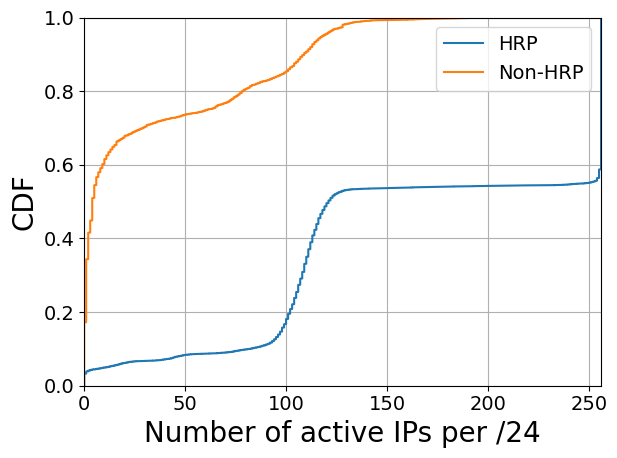

In [28]:
# plot distribution of active IPs for HRP and non-HRP

import numpy as np
# split data
hrp = census_v4[census_v4['is_hrp'] == True]['number_of_active_ips']
non_hrp = census_v4[census_v4['is_hrp'] == False]['number_of_active_ips']

hrp_sorted = np.sort(hrp)
non_hrp_sorted = np.sort(non_hrp)

hrp_cdf = np.arange(1, len(hrp_sorted) + 1) / len(hrp_sorted)
non_hrp_cdf = np.arange(1, len(non_hrp_sorted) + 1) / len(non_hrp_sorted)

plt.figure()

plt.plot(hrp_sorted, hrp_cdf, label="HRP")
plt.plot(non_hrp_sorted, non_hrp_cdf, label="Non-HRP")

plt.xlabel("Number of active IPs per /24")
plt.ylabel("CDF")
plt.xlim(0, 256)
plt.ylim(0, 1)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


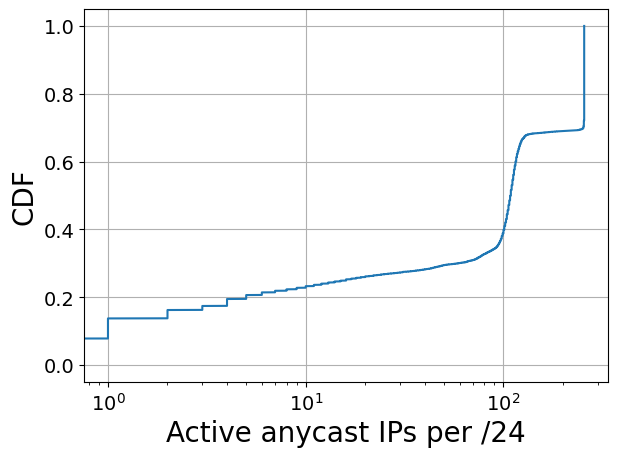

In [29]:
sorted_ips = np.sort(census_v4['number_of_active_ips'].values)
cdf = np.arange(1, len(sorted_ips) + 1) / len(sorted_ips)

plt.figure()
plt.plot(sorted_ips, cdf)
plt.xscale('log')
plt.xlabel("Active anycast IPs per /24")
plt.ylabel("CDF")
plt.grid(True)
plt.tight_layout()
plt.show()

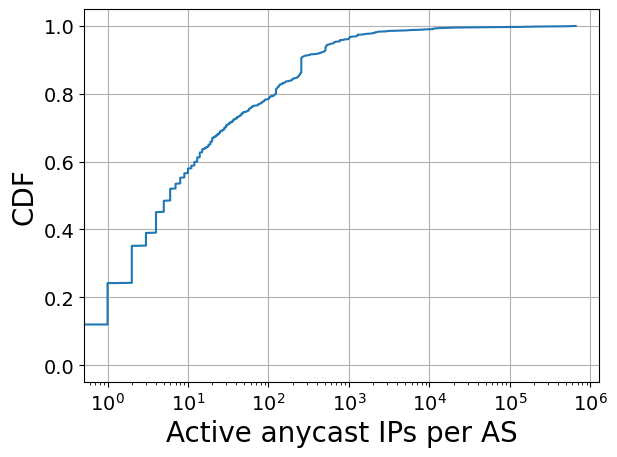

In [30]:
# aggregate per ASN (handle MOAS)
asn_ips = (
    census_v4.assign(ASN=census_v4['ASN'].str.split('_'))
    .explode('ASN')
    .groupby('ASN')['number_of_active_ips']
    .sum()
)

sorted_ips = np.sort(asn_ips.values)
cdf = np.arange(1, len(sorted_ips) + 1) / len(sorted_ips)

plt.figure()
plt.plot(sorted_ips, cdf)
plt.xscale('log')
plt.xlabel("Active anycast IPs per AS")
plt.ylabel("CDF")
plt.grid(True)
plt.tight_layout()
plt.show()

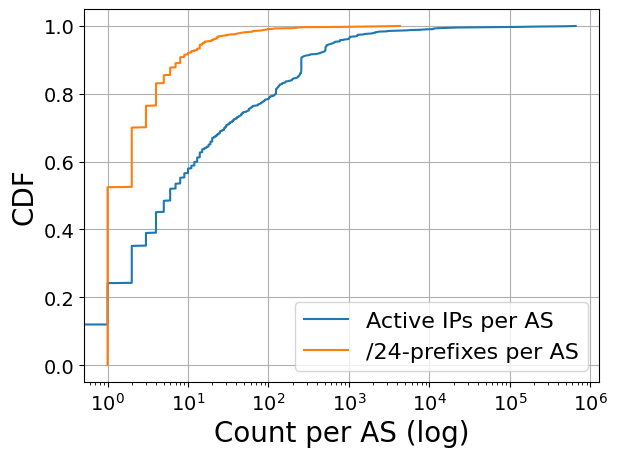

In [31]:
asn_exploded = (
    census_v4.assign(ASN=census_v4['ASN'].str.split('_'))
    .explode('ASN')
)

asn_ips = asn_exploded.groupby('ASN')['number_of_active_ips'].sum()
asn_prefixes = asn_exploded.groupby('ASN')['prefix'].nunique()

sorted_ips = np.sort(asn_ips.values)
cdf_ips = np.arange(1, len(sorted_ips) + 1) / len(sorted_ips)

sorted_prefixes = np.sort(asn_prefixes.values)
cdf_prefixes = np.arange(1, len(sorted_prefixes) + 1) / len(sorted_prefixes)

plt.figure()
plt.plot(sorted_ips, cdf_ips, label="Active IPs per AS")
plt.plot(sorted_prefixes, cdf_prefixes, label="/24-prefixes per AS")
plt.xscale('log')
plt.xlabel("Count per AS (log)")
plt.ylabel("CDF")
plt.grid(True)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("as_cdf.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [32]:
asn_table

,ASN,active_ips,slash24s,IP Utilization,HRP
64,13335,657528,2866,0.896186,0.989184
666,396982,491593,4298,0.446786,0.973476
915,54113,209398,827,0.989070,0.990326
158,16509,133371,1603,0.325003,0.259513
322,209242,59549,270,0.861531,0.966667
...,...,...,...,...,...
585,36236,0,1,0.000000,0.000000
597,36732,0,1,0.000000,1.000000
634,395954,0,2,0.000000,0.000000
636,396190,0,2,0.000000,0.000000


In [33]:
asn_table[asn_table['IP Utilization'] <= 0.33]

,ASN,active_ips,slash24s,IP Utilization,HRP
158,16509,133371,1603,0.325003,0.259513
154,15967,11173,195,0.223818,0.958974
557,33905,4191,51,0.321002,0.000000
858,48851,2347,40,0.229199,0.300000
136,15169,2284,116,0.076913,0.620690
...,...,...,...,...,...
585,36236,0,1,0.000000,0.000000
597,36732,0,1,0.000000,1.000000
634,395954,0,2,0.000000,0.000000
636,396190,0,2,0.000000,0.000000


In [34]:
asn_table[asn_table['IP Utilization'] <= 0.10]


,ASN,active_ips,slash24s,IP Utilization,HRP
136,15169,2284,116,0.076913,0.620690
32,12041,2138,228,0.036630,0.000000
1043,8075,1082,64,0.066040,0.000000
775,42,996,64,0.060791,0.000000
1004,63911,861,98,0.034319,0.030612
...,...,...,...,...,...
585,36236,0,1,0.000000,0.000000
597,36732,0,1,0.000000,1.000000
634,395954,0,2,0.000000,0.000000
636,396190,0,2,0.000000,0.000000


In [35]:
asn_table[asn_table['IP Utilization'] > 0.90]

,ASN,active_ips,slash24s,IP Utilization,HRP
915,54113,209398,827,0.989070,0.990326
695,398787,16383,64,0.999939,1.000000
50,13150,2138,9,0.927951,0.888889
505,30081,1968,8,0.960938,0.875000
285,205634,1888,8,0.921875,1.000000
...,...,...,...,...,...
149,154204,248,1,0.968750,1.000000
380,214618,248,1,0.968750,1.000000
340,210250,246,1,0.960938,1.000000
247,201303,241,1,0.941406,1.000000


In [36]:
asn_table[asn_table['IP Utilization'] > 0.66]

,ASN,active_ips,slash24s,IP Utilization,HRP
64,13335,657528,2866,0.896186,0.989184
915,54113,209398,827,0.989070,0.990326
322,209242,59549,270,0.861531,0.966667
695,398787,16383,64,0.999939,1.000000
878,51115,3010,14,0.839844,0.857143
...,...,...,...,...,...
101,140577,205,1,0.800781,1.000000
920,54456,199,1,0.777344,1.000000
347,210753,185,1,0.722656,1.000000
356,212085,181,1,0.707031,1.000000


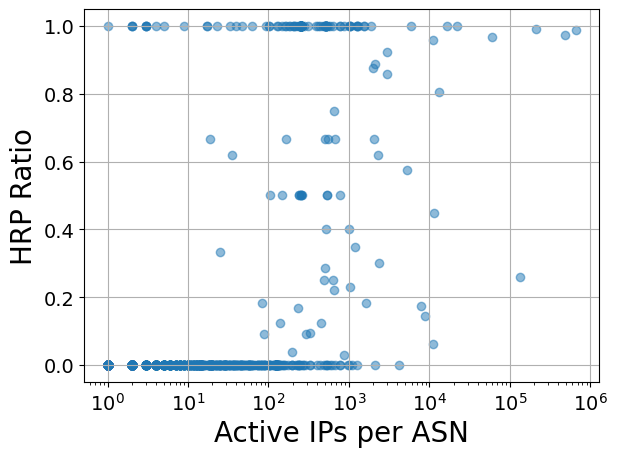

In [37]:
plt.figure()

plt.scatter(
    asn_table['active_ips'],
    asn_table['HRP'],
    alpha=0.5
)

plt.xscale('log')
plt.xlabel("Active IPs per ASN")
plt.ylabel("HRP Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

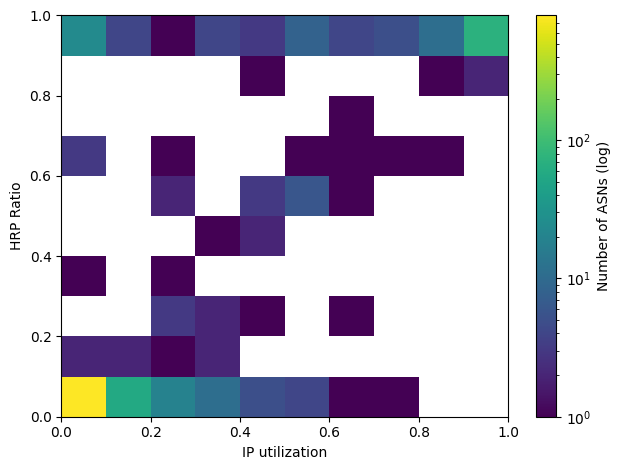

In [74]:
x = asn_table['IP Utilization']
y = asn_table['HRP']

plt.style.use("default")


plt.figure()

# x_bins = np.logspace(
#     np.log10(x[x > 0].min()),
#     np.log10(x.max()),
#     50
# )

x_bins = np.linspace(0, 1, 11)
y_bins = np.linspace(0, 1, 11)
from matplotlib.colors import LogNorm

plt.hist2d(x, y, bins=[x_bins, y_bins],
           norm=LogNorm())

# plt.xscale('log')

fontsize=10
plt.xlabel("IP utilization", fontsize=fontsize)
plt.ylabel("HRP Ratio", fontsize=fontsize)

plt.colorbar(label="Number of ASNs (log)")

plt.tight_layout()
plt.savefig("as_ip_hrp_heatmap.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [39]:
# Top-left: low IP utilization, high HRP
top_left = asn_table[(asn_table['IP Utilization'] < 0.33) & (asn_table['HRP'] > 0.66)]
top_left

,ASN,active_ips,slash24s,IP Utilization,HRP
154,15967,11173,195,0.223818,0.958974
94,139070,274,9,0.118924,1.000000
901,53332,165,3,0.214844,0.666667
201,19527,162,8,0.079102,1.000000
745,40279,63,2,0.123047,1.000000
324,209299,47,1,0.183594,1.000000
253,201706,40,1,0.156250,1.000000
1008,64089,33,5,0.025781,1.000000
312,208185,23,1,0.089844,1.000000
512,30456,19,3,0.024740,0.666667


In [40]:
# Bottom-left: low IP utilization, low HRP
bottom_left = asn_table[(asn_table['IP Utilization'] < 0.33) & (asn_table['HRP'] < 0.33)]
bottom_left

,ASN,active_ips,slash24s,IP Utilization,HRP
158,16509,133371,1603,0.325003,0.259513
557,33905,4191,51,0.321002,0.000000
858,48851,2347,40,0.229199,0.300000
32,12041,2138,228,0.036630,0.000000
814,45102,1642,22,0.291548,0.181818
...,...,...,...,...,...
542,32787,0,1,0.000000,0.000000
585,36236,0,1,0.000000,0.000000
634,395954,0,2,0.000000,0.000000
636,396190,0,2,0.000000,0.000000


In [41]:
# how many ASes have low IP and HRP utilization?
bottom_left['ASN'].nunique()

885

In [42]:
high_utilization = asn_table[(asn_table['IP Utilization'] > 0.66)]
high_utilization['ASN'].str.split('_').explode().nunique()

97

In [43]:
low_utilization = asn_table[(asn_table['IP Utilization'] <= 0.33)]
low_utilization['ASN'].str.split('_').explode().nunique()

922

In [44]:
# Bottom-right: high IP utilization, low HRP
bottom_right = asn_table[(asn_table['IP Utilization'] > 0.66) & (asn_table['HRP'] < 0.33)]
bottom_right

,ASN,active_ips,slash24s,IP Utilization,HRP
148,15418,772,4,0.753906,0.0
106,14116,175,1,0.683594,0.0


In [45]:
# Center: mid IP utilization, mid HRP
center = asn_table[
    (asn_table['IP Utilization'].between(0.33, 0.66)) &
    (asn_table['HRP'].between(0.33, 0.66))
]
center

,ASN,active_ips,slash24s,IP Utilization,HRP
31,12008,11514,98,0.458945,0.448980
438,24429,5241,33,0.620384,0.575758
348,210756,998,10,0.389844,0.400000
327,209453,772,6,0.502604,0.500000
219,198412,528,4,0.515625,0.500000
838,47583,527,4,0.514648,0.500000
606,37963,516,5,0.403125,0.400000
1009,64199,262,2,0.511719,0.500000
756,40680,257,2,0.501953,0.500000
632,395831,257,2,0.501953,0.500000


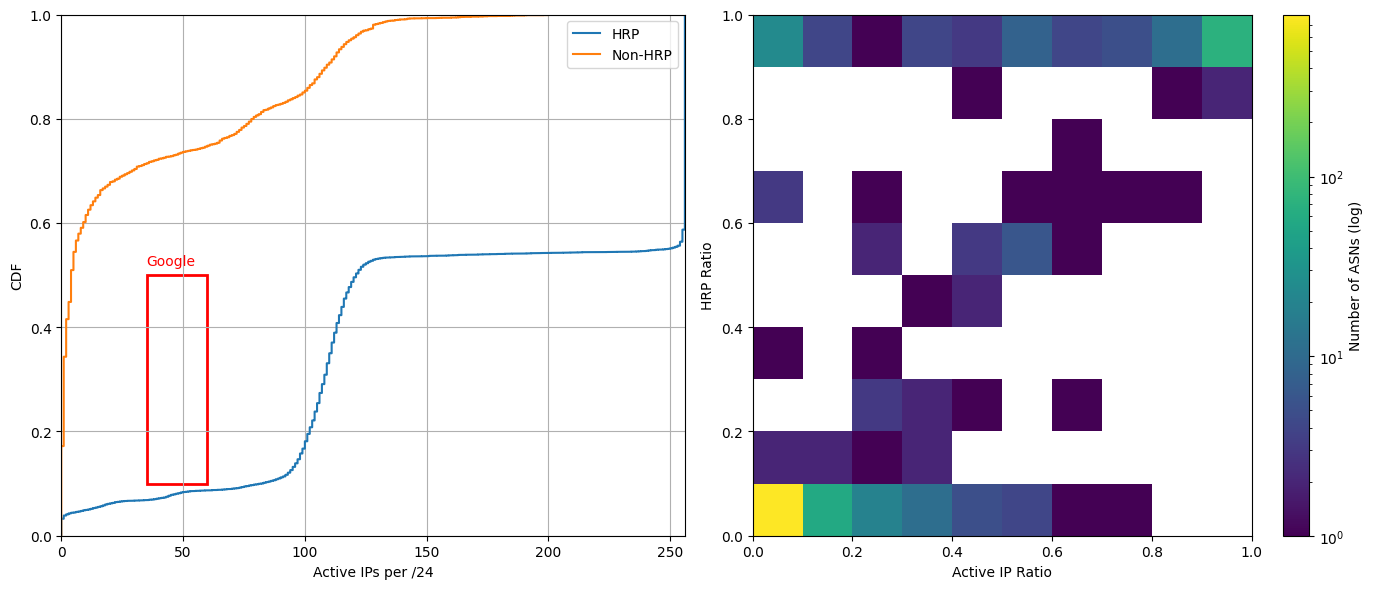

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# =========================
# LEFT PANEL — CDF (/24)
# =========================

hrp = census_v4[census_v4['is_hrp'] == True]['number_of_active_ips']
non_hrp = census_v4[census_v4['is_hrp'] == False]['number_of_active_ips']

hrp_sorted = np.sort(hrp)
non_hrp_sorted = np.sort(non_hrp)

hrp_cdf = np.arange(1, len(hrp_sorted) + 1) / len(hrp_sorted)
non_hrp_cdf = np.arange(1, len(non_hrp_sorted) + 1) / len(non_hrp_sorted)

ax1.step(hrp_sorted, hrp_cdf, where='post', label="HRP")
ax1.step(non_hrp_sorted, non_hrp_cdf, where='post', label="Non-HRP")

ax1.set_xlabel("Active IPs per /24")
ax1.set_ylabel("CDF")
ax1.set_xlim(0, 256)
ax1.set_ylim(0, 1)

from matplotlib.patches import Rectangle

# Define box: x=35–55, y=0.10–0.50
rect = Rectangle(
    (35, 0.10),   # bottom-left corner
    60-35,        # width
    0.50-0.10,    # height
    fill=False,
    edgecolor='red',
    linewidth=2
)

ax1.add_patch(rect)

# Add label
ax1.text(45, 0.52, "Google", color='red', ha='center')


ax1.grid(True)
ax1.legend()


# =========================
# RIGHT PANEL — ASN Heatmap
# =========================


x = asn_table['IP Utilization']
y = asn_table['HRP']

x_bins = np.linspace(0, 1, 11)
y_bins = np.linspace(0, 1, 11)

hist = ax2.hist2d(
    x,
    y,
    bins=[x_bins, y_bins],
    norm=LogNorm()
)

ax2.set_xlabel("Active IP Ratio")
ax2.set_ylabel("HRP Ratio")

cbar = fig.colorbar(hist[3], ax=ax2)
cbar.set_label("Number of ASNs (log)")

plt.savefig("ip_utilization.pdf", bbox_inches='tight', pad_inches=0)

plt.tight_layout()
plt.show()


In [47]:
# which AS originates 35-50 active IPs for HRP prefixes

hrp = census_v4[census_v4['is_hrp']]
hrp_filtered = hrp[(hrp['number_of_active_ips'] > 35) & (hrp['number_of_active_ips'] < 65)]
hrp_filtered

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization
5453,134.231.242.0/24,5,0,0,5,0,False,134.231.242.0/24,63911,"[{'city': 'Sydney', 'country_code': 'AU', 'id'...",True,37,0.144531
5707,136.110.193.0/24,18,0,0,62,0,False,136.108.0.0/14,396982,"[{'city': 'Miami', 'country_code': 'US', 'id':...",True,61,0.238281
5715,136.110.201.0/24,18,0,0,60,10,False,136.108.0.0/14,396982,"[{'city': None, 'country_code': None, 'id': 'N...",True,62,0.242188
5727,136.110.213.0/24,18,0,0,62,0,False,136.108.0.0/14,396982,"[{'city': None, 'country_code': None, 'id': 'N...",True,64,0.250000
5745,136.110.231.0/24,18,0,0,61,0,False,136.108.0.0/14,396982,"[{'city': None, 'country_code': None, 'id': 'N...",True,62,0.242188
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33440,85.128.252.0/24,5,0,0,6,0,False,85.128.192.0/18,15967,"[{'city': 'Los Angeles', 'country_code': 'US',...",True,45,0.175781
33441,85.128.253.0/24,5,0,0,6,0,False,85.128.192.0/18,15967,"[{'city': 'Los Angeles', 'country_code': 'US',...",True,44,0.171875
33442,85.128.254.0/24,5,0,0,6,0,False,85.128.192.0/18,15967,"[{'city': 'Singapore', 'country_code': 'SG', '...",True,38,0.148438
33443,85.128.255.0/24,5,0,0,6,0,False,85.128.192.0/18,15967,"[{'city': 'Los Angeles', 'country_code': 'US',...",True,46,0.179688


In [48]:
hrp_filtered.groupby('ASN')['prefix'].nunique().sort_values(ascending=False)

ASN
15967     164
396982     13
25773       4
12008       1
19437       1
19527       1
201706      1
209242      1
209299      1
394089      1
40279       1
63911       1
Name: prefix, dtype: int64

In [49]:
# where do anycast operators deploy?

census_v4['locations'].head(1)

0    [{'city': 'Honolulu', 'country_code': 'US', 'i...
Name: locations, dtype: object

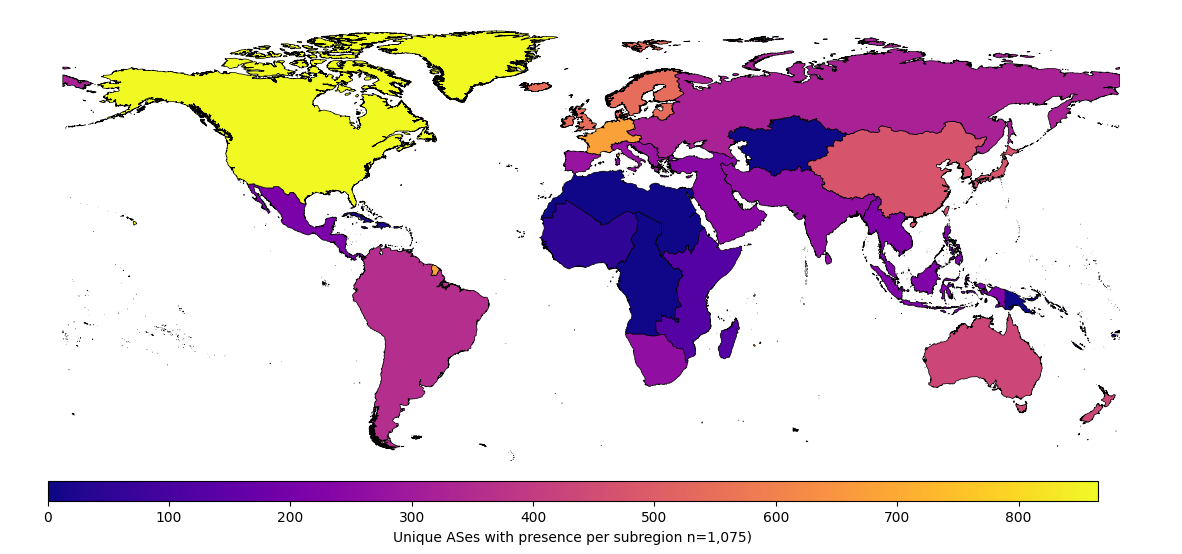

In [50]:
import ast
import geopandas as gpd

# # explode locations
census_v4_locs = census_v4.copy()
census_v4_locs['locations'] = census_v4_locs['locations'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
census_v4_locs = census_v4_locs.explode('locations')
census_v4_locs['lat'] = census_v4_locs['locations'].apply(lambda x: x['lat'])
census_v4_locs['lon'] = census_v4_locs['locations'].apply(lambda x: x['lon'])

# load world map
url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
world = gpd.read_file(url)
if 'ADM0_A3' in world.columns:
    world = world.rename(columns={'ADM0_A3': 'iso_a3'})
world = world[world['iso_a3'] != 'ATA']

# spatial join: assign each point to a country/subregion
points = gpd.GeoDataFrame(
    census_v4_locs,
    geometry=gpd.points_from_xy(census_v4_locs['lon'], census_v4_locs['lat']),
    crs='EPSG:4326'
)
joined = gpd.sjoin(points, world[['geometry', 'SUBREGION']], how='left', predicate='within')

# need to explode MOAS ASNs too
joined_exploded = joined.assign(ASN=joined['ASN'].str.split('_')).explode('ASN')

region_stats = joined_exploded.groupby('SUBREGION')['ASN'].nunique().reset_index(name='unique_ases')


# dissolve world by subregion and merge counts
region_map = world.dissolve(by='SUBREGION')
region_map = region_map.merge(region_stats, on='SUBREGION', how='left')
region_map['unique_ases'] = region_map['unique_ases'].fillna(0)

# plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
region_map.plot(
    column='unique_ases',
    ax=ax,
    legend=False,
    legend_kwds={'label': f'Unique ASes with presence per subregion (n={joined_exploded['ASN'].nunique():,})', 'orientation': 'horizontal', 'shrink': 0.7},
    cmap='plasma',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)
legend_kwds={'label': '...', 'orientation': 'horizontal', 'shrink': 0.7, 'pad': 0.02}


# ax.set_ylim(-60, 90)

cax = fig.add_axes([0.15, 0.24, 0.7, 0.02])
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=region_map['unique_ases'].min(), vmax=region_map['unique_ases'].max()))
fig.colorbar(sm, cax=cax, orientation='horizontal', label=f'Unique ASes with presence per subregion n={joined_exploded['ASN'].nunique():,})')

ax.set_axis_off()
plt.savefig("map_subregion_heatmap.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [51]:
import requests, io
import pandas as pd

# download UN WPP 2024 population estimates
url = "https://population.un.org/wpp/assets/Excel%20Files/1_Indicator%20(Standard)/CSV_FILES/WPP2024_TotalPopulationBySex.csv.gz"
r = requests.get(url, timeout=30)
un_pop = pd.read_csv(io.BytesIO(r.content), compression='gzip')

# filter to 2025 medium variant, country-level only (LocTypeID == 4)
un_pop_2025 = un_pop[
    (un_pop['Time'] == 2025) &
    (un_pop['Variant'] == 'Medium') &
    (un_pop['LocTypeID'] == 4)
][['ISO3_code', 'PopTotal']].copy()

# PopTotal is in thousands
un_pop_2025['population'] = un_pop_2025['PopTotal'] * 1000

# merge with Natural Earth on iso_a3
world_pop = world.merge(un_pop_2025[['ISO3_code', 'population']],
                        left_on='iso_a3', right_on='ISO3_code', how='left')

# aggregate population to subregion
pop_by_region = (
    world_pop.groupby('SUBREGION')['population']
    .sum()
    .reset_index(name='population')
)

# merge into region_map
region_map = world.dissolve(by='SUBREGION')
region_map = region_map.merge(region_stats, on='SUBREGION', how='left')
region_map = region_map.merge(pop_by_region, on='SUBREGION', how='left')
region_map['unique_ases'] = region_map['unique_ases'].fillna(0)
region_map['ases_per_million'] = region_map['unique_ases'] / (region_map['population'] / 1_000_000)

print(f"Countries matched: {un_pop_2025['ISO3_code'].isin(world['iso_a3']).sum()} / {len(un_pop_2025)}")
print(pop_by_region.sort_values('population', ascending=False))

/var/folders/k_/b2zc8kg571bcqh2l9j8mj82h0000gn/T/ipykernel_66864/3969170834.py:7: DtypeWarning: Columns (0: Notes, 1: ISO3_code, 2: ISO2_code, 3: LocTypeName) have mixed types. Specify dtype option on import or set low_memory=False.
  un_pop = pd.read_csv(io.BytesIO(r.content), compression='gzip')


Countries matched: 226 / 237
                    SUBREGION    population
18              Southern Asia  2.085208e+09
5                Eastern Asia  1.652186e+09
16         South-Eastern Asia  7.000317e+08
4              Eastern Africa  5.000775e+08
20             Western Africa  4.665328e+08
15              South America  4.377917e+08
11           Northern America  3.875284e+08
21               Western Asia  3.087076e+08
6              Eastern Europe  2.844520e+08
10            Northern Africa  2.757014e+08
9               Middle Africa  2.195251e+08
22             Western Europe  1.996712e+08
2             Central America  1.851607e+08
19            Southern Europe  1.491018e+08
12            Northern Europe  1.094997e+08
3                Central Asia  8.359780e+07
17            Southern Africa  7.402176e+07
1                   Caribbean  4.387691e+07
0   Australia and New Zealand  3.222592e+07
7                   Melanesia  1.316512e+07
13                  Polynesia  6.873120e+05
8  

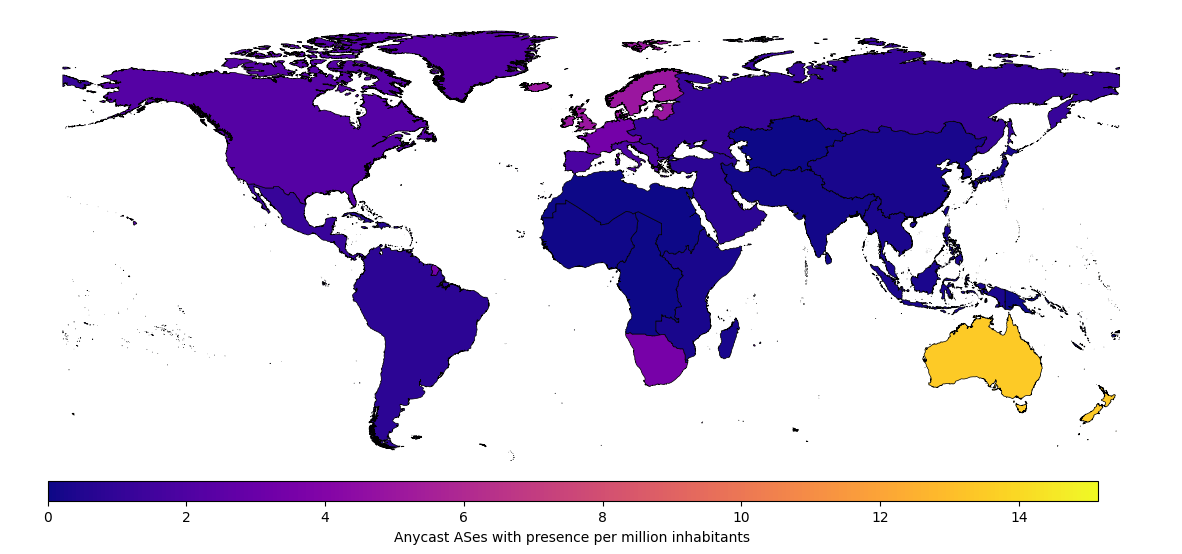

In [52]:
# aggregate population per subregion from Natural Earth
# pop_by_region = (
#     world.groupby('SUBREGION')['POP_EST']
#     .sum()
#     .reset_index(name='population')
# )



# merge population into region_map
region_map = world.dissolve(by='SUBREGION')
region_map = region_map.merge(region_stats, on='SUBREGION', how='left')
region_map = region_map.merge(pop_by_region, on='SUBREGION', how='left')
region_map['unique_ases'] = region_map['unique_ases'].fillna(0)

# normalize: ASes per million people
region_map['ases_per_million'] = (
    region_map['unique_ases'] / (region_map['population'] / 1_000_000)
)

# plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
region_map.plot(
    column='ases_per_million',
    ax=ax,
    cmap='plasma',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)

cax = fig.add_axes([0.15, 0.24, 0.7, 0.02])
sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=plt.Normalize(
        vmin=region_map['ases_per_million'].min(),
        vmax=region_map['ases_per_million'].max()
    )
)
fig.colorbar(
    sm, cax=cax, orientation='horizontal',
    label=f'Anycast ASes with presence per million inhabitants',
    # label=f'Anycast ASes per million people (n={joined_exploded["ASN"].nunique():,})'
)

ax.set_axis_off()
plt.savefig("map_subregion_heatmap_per_capita.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

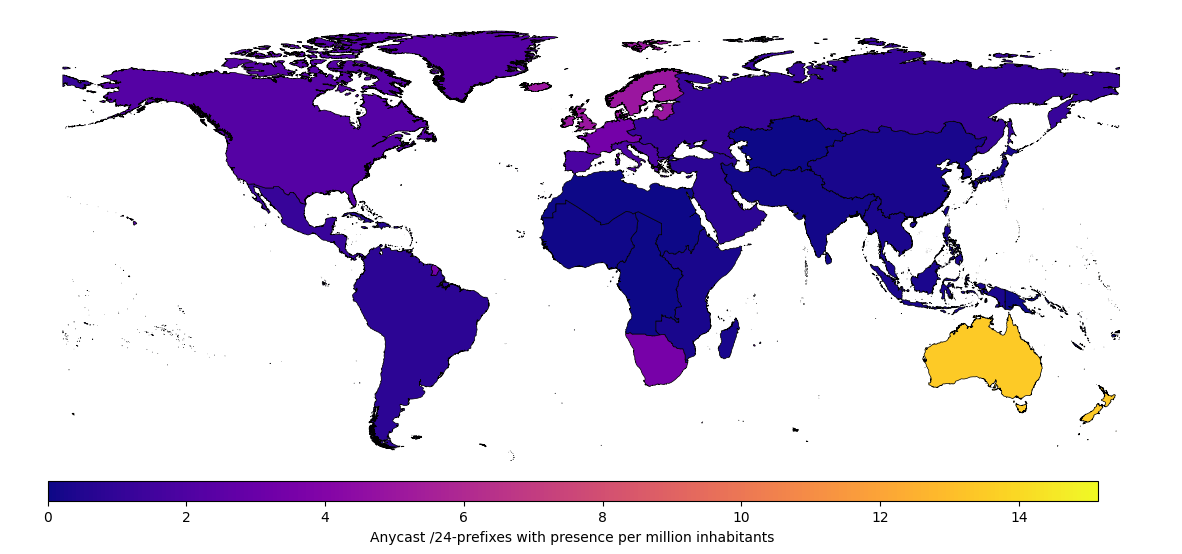

In [53]:
# aggregate population per subregion from Natural Earth
# pop_by_region = (
#     world.groupby('SUBREGION')['POP_EST']
#     .sum()
#     .reset_index(name='population')
# )



# merge population into region_map
region_map = world.dissolve(by='SUBREGION')
region_map = region_map.merge(region_stats, on='SUBREGION', how='left')
region_map = region_map.merge(pop_by_region, on='SUBREGION', how='left')
region_map['unique_ases'] = region_map['unique_ases'].fillna(0)

# normalize: ASes per million people
region_map['ases_per_million'] = (
    region_map['unique_ases'] / (region_map['population'] / 1_000_000)
)

# plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
region_map.plot(
    column='ases_per_million',
    ax=ax,
    cmap='plasma',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)

cax = fig.add_axes([0.15, 0.24, 0.7, 0.02])
sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=plt.Normalize(
        vmin=region_map['ases_per_million'].min(),
        vmax=region_map['ases_per_million'].max()
    )
)
fig.colorbar(
    sm, cax=cax, orientation='horizontal',
    label=f'Anycast /24-prefixes with presence per million inhabitants',
    # label=f'Anycast ASes per million people (n={joined_exploded["ASN"].nunique():,})'
)

ax.set_axis_off()
plt.savefig("map_subregion_heatmap_per_capita.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

In [54]:
joined[joined['geometry'].apply(lambda p: abs(p.x - 144.7) < 1 and abs(p.y - 13.4) < 1)][['SUBREGION']].value_counts()


SUBREGION 
Micronesia    2655
Name: count, dtype: int64

In [55]:
print(joined[joined['SUBREGION'].isna()][['lat', 'lon', 'prefix', 'ASN']].head(20))


         lat        lon            prefix           ASN
0   22.30889  113.91472        1.0.0.0/24         13335
0    1.35019  103.99400        1.0.0.0/24         13335
0   64.13000  -21.94060        1.0.0.0/24         13335
1   22.30889  113.91472        1.1.1.0/24         13335
1    1.35019  103.99400        1.1.1.0/24         13335
1   64.13000  -21.94060        1.1.1.0/24         13335
4   22.30889  113.91472       1.12.0.0/24  132203_45090
4    1.35019  103.99400       1.12.0.0/24  132203_45090
5   22.30889  113.91472      1.12.12.0/24  132203_45090
6   22.30889  113.91472      1.12.13.0/24  132203_45090
7   22.30889  113.91472      1.12.14.0/24  132203_45090
8   22.30889  113.91472      1.12.15.0/24  132203_45090
9   22.30889  113.91472      1.12.34.0/24  132203_45090
70  22.30889  113.91472   101.32.132.0/24        132203
70   1.35019  103.99400   101.32.132.0/24        132203
75  22.30889  113.91472    101.33.41.0/24        132203
80   1.35019  103.99400   101.79.220.0/24       

In [56]:
print(joined[(joined['lon'].between(143, 146)) & (joined['lat'].between(12, 15))][['SUBREGION', 'prefix', 'ASN']])

        SUBREGION          prefix    ASN
0      Micronesia      1.0.0.0/24  13335
1      Micronesia      1.1.1.0/24  13335
485    Micronesia   104.16.0.0/24  13335
486    Micronesia   104.16.1.0/24  13335
487    Micronesia  104.16.10.0/24  13335
...           ...             ...    ...
33066  Micronesia   8.39.204.0/24  13335
33067  Micronesia   8.39.214.0/24  13335
33074  Micronesia    8.47.69.0/24  13335
33075  Micronesia    8.6.112.0/24  13335
34044  Micronesia      9.9.9.0/24  19281

[2655 rows x 3 columns]


Empty GeoDataFrame
Columns: [SUBREGION, geometry, featurecla, scalerank, LABELRANK, SOVEREIGNT, SOV_A3, ADM0_DIF, LEVEL, TYPE, TLC, ADMIN, iso_a3, GEOU_DIF, GEOUNIT, GU_A3, SU_DIF, SUBUNIT, SU_A3, BRK_DIFF, NAME, NAME_LONG, BRK_A3, BRK_NAME, BRK_GROUP, ABBREV, POSTAL, FORMAL_EN, FORMAL_FR, NAME_CIAWF, NOTE_ADM0, NOTE_BRK, NAME_SORT, NAME_ALT, MAPCOLOR7, MAPCOLOR8, MAPCOLOR9, MAPCOLOR13, POP_EST, POP_RANK, POP_YEAR, GDP_MD, GDP_YEAR, ECONOMY, INCOME_GRP, FIPS_10, ISO_A2, ISO_A2_EH, ISO_A3, ISO_A3_EH, ISO_N3, ISO_N3_EH, UN_A3, WB_A2, WB_A3, WOE_ID, WOE_ID_EH, WOE_NOTE, ADM0_ISO, ADM0_DIFF, ADM0_TLC, ADM0_A3_US, ADM0_A3_FR, ADM0_A3_RU, ADM0_A3_ES, ADM0_A3_CN, ADM0_A3_TW, ADM0_A3_IN, ADM0_A3_NP, ADM0_A3_PK, ADM0_A3_DE, ADM0_A3_GB, ADM0_A3_BR, ADM0_A3_IL, ADM0_A3_PS, ADM0_A3_SA, ADM0_A3_EG, ADM0_A3_MA, ADM0_A3_PT, ADM0_A3_AR, ADM0_A3_JP, ADM0_A3_KO, ADM0_A3_VN, ADM0_A3_TR, ADM0_A3_ID, ADM0_A3_PL, ADM0_A3_GR, ADM0_A3_IT, ADM0_A3_NL, ADM0_A3_SE, ADM0_A3_BD, ADM0_A3_UA, ADM0_A3_UN, ADM0_A3_WB,

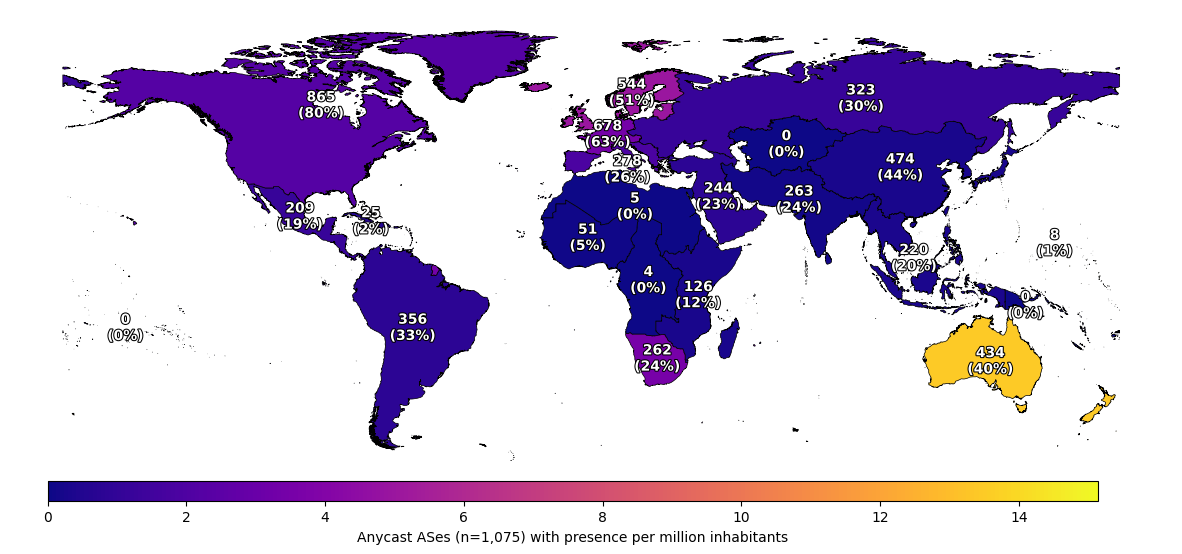

In [57]:
from matplotlib.colors import LogNorm
import matplotlib.patheffects as pe

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

region_map.plot(
    column='ases_per_million',
    ax=ax,
    cmap='plasma',
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)

# compute total for percentage
total_ases = joined_exploded['ASN'].nunique()

# manual offsets for crowded subregions (lon_offset, lat_offset)
offsets = {
    'Western Europe':  (2, 3),
    'Southern Europe': (5, -4),
    'Micronesia':      (65, 5),  # nudge right and up, away from Indonesia
}

print(region_map[region_map.index == 'Central Asia'])

for idx, row in region_map.iterrows():
    if pd.isna(row['unique_ases']):
        continue

    if row['SUBREGION'] == 'Seven seas (open ocean)':
        continue # not a subregion


    centroid = row['geometry'].centroid
    n   = int(row['unique_ases'])
    print(f'n = {n:,}')
    print(row['SUBREGION'])
    pct = round(n / total_ases * 100)

    print(row['SUBREGION'])

    dx, dy = offsets.get(row['SUBREGION'], (0, 0))

    ax.text(
        centroid.x + dx, centroid.y + dy,
        f"{n}\n({pct}%)",
        ha='center', va='center',
        fontsize=10,
        fontweight='bold',
        color='white',
        path_effects=[pe.withStroke(linewidth=1.5, foreground='black')]
    )

cax = fig.add_axes([0.15, 0.24, 0.7, 0.02])
sm = plt.cm.ScalarMappable(
    cmap='plasma',
    norm=plt.Normalize(
        vmin=region_map['ases_per_million'].min(),
        vmax=region_map['ases_per_million'].max()
    )
)
fig.colorbar(
    sm, cax=cax, orientation='horizontal',
    label=f'Anycast ASes (n={total_ases:,}) with presence per million inhabitants'
)

ax.set_axis_off()
plt.savefig("map_subregion_heatmap_per_capita.pdf", bbox_inches='tight', pad_inches=0)
plt.show()

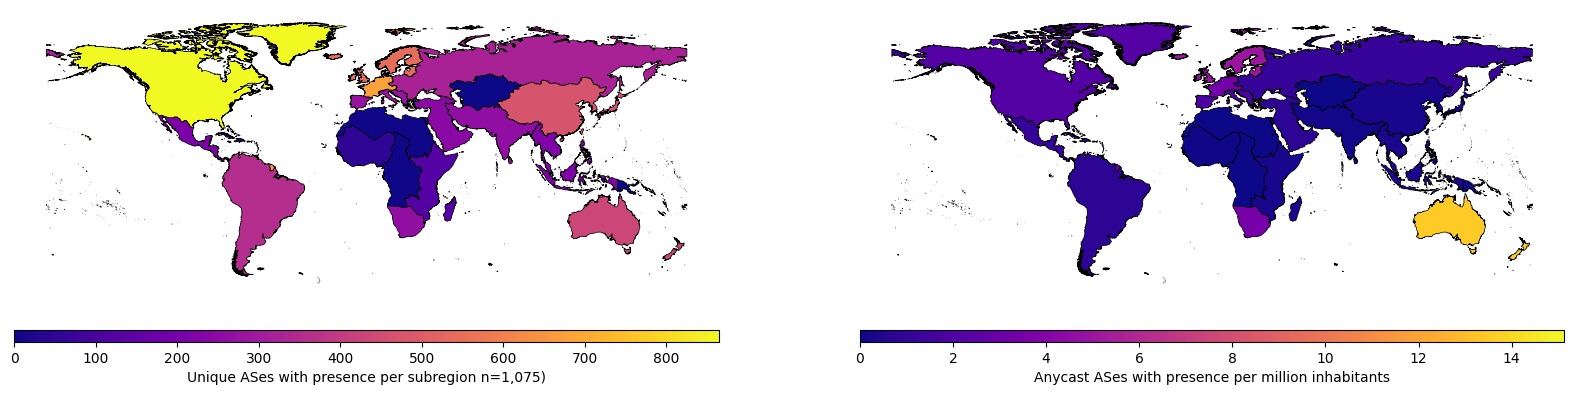

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, col, label in zip(
    axes,
    ['unique_ases', 'ases_per_million'],
    [
        f'Unique ASes with presence per subregion n={joined_exploded['ASN'].nunique():,})',
     f'Anycast ASes with presence per million inhabitants',]
):
    region_map.plot(
        column=col,
        ax=ax,
        cmap='plasma',
        edgecolor='black',
        linewidth=0.5,
        missing_kwds={'color': 'lightgrey'}
    )
    cax = fig.add_axes([
        ax.get_position().x0,
        0.18,
        ax.get_position().width,
        0.02
    ])
    sm = plt.cm.ScalarMappable(
        cmap='plasma',
        norm=plt.Normalize(
            vmin=region_map[col].min(),
            vmax=region_map[col].max()
        )
    )
    fig.colorbar(sm, cax=cax, orientation='horizontal', label=label)
    ax.set_axis_off()

plt.savefig("map_subregion_heatmap_both.pdf", bbox_inches='tight', pad_inches=0)
plt.show()


In [59]:
from matplotlib.colors import LogNorm

def plot_map(col, label, filename):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    norm = LogNorm(
        vmin=max(region_map[col].min(), 0.01),
        vmax=region_map[col].max()
    )
    region_map.plot(
        column=col,
        ax=ax,
        cmap='plasma',
        norm=norm,
        edgecolor='black',
        linewidth=0.5,
        missing_kwds={'color': 'lightgrey'}
    )
    cax = fig.add_axes([0.15, 0.12, 0.7, 0.02])
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
    fig.colorbar(sm, cax=cax, orientation='horizontal', label=label)
    ax.set_axis_off()
    plt.savefig(filename, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"Saved {filename}")

plot_map(
    'unique_ases',
    f'Anycast ASes per subregion (n={int(region_map["unique_ases"].sum())})',
    'map_absolute.pdf'
)

plot_map(
    'ases_per_million',
    'Anycast ASes per million people (UN WPP 2025)',
    'map_normalized.pdf'
)

Saved map_absolute.pdf
Saved map_normalized.pdf


In [60]:
# figure out regional anycast ASNs


In [61]:
# !pip install reverse_geocoder
# ! pip install pycountry_convert
import reverse_geocoder as rg
import pycountry_convert as pc


def classify_anycast_fast(df):
    """
    classify anycast prefixes as
    a) global -> spanning multiple continents
    b) continental -> within a single continent
    c) national -> within a single country
    """
    # convert `locations` object to a pandas list for processing
    def clean_loc(x):
        if isinstance(x, np.ndarray): return x.tolist()
        if isinstance(x, str):
            try: return ast.literal_eval(x)
            except: return []
        return x if isinstance(x, list) else []

    df['clean_locations'] = df['locations'].apply(clean_loc)

    # save original index
    df = df.reset_index().rename(columns={'index': 'original_id'})

    # explode -> a row for each location
    df_exploded = df.explode('clean_locations')
    df_exploded = df_exploded.dropna(subset=['clean_locations'])

    # get lat, lon values for each location
    coords_df = pd.DataFrame(df_exploded['clean_locations'].tolist())

    coords_df['lat'] = pd.to_numeric(coords_df['lat'], errors='coerce')
    coords_df['lon'] = pd.to_numeric(coords_df['lon'], errors='coerce')

    # filter out NaN coords
    valid_indices = coords_df.dropna(subset=['lat', 'lon']).index
    df_exploded = df_exploded.iloc[valid_indices].copy()
    df_exploded['lat'] = coords_df.loc[valid_indices, 'lat'].values
    df_exploded['lon'] = coords_df.loc[valid_indices, 'lon'].values

    # get unique locations (many duplicate airports in data)
    unique_coords = df_exploded[['lat', 'lon']].drop_duplicates()
    coords_tuple = list(zip(unique_coords['lat'], unique_coords['lon']))

    if not coords_tuple:
        return df

    print(f"Batch geocoding {len(coords_tuple)} unique locations...")
    geo_results = rg.search(coords_tuple, verbose=False)

    # lookup dataframe: Lat/Lon -> Country Code
    geo_df = pd.DataFrame(geo_results)
    geo_df['lat'] = unique_coords['lat'].values
    geo_df['lon'] = unique_coords['lon'].values
    geo_df = geo_df[['lat', 'lon', 'cc']] # Keep Country Code

    # map: Country Code -> Continent
    found_country_codes = geo_df['cc'].unique()
    continent_map = {}

    for cc in found_country_codes:
        try:
            continent_map[cc] = pc.country_alpha2_to_continent_code(cc)
        except:
            continent_map[cc] = 'Unknown'

    # Map the continent to the geocoded results
    geo_df['continent'] = geo_df['cc'].map(continent_map)

    # join continent and country code back in original coord df
    merged = df_exploded.merge(geo_df, on=['lat', 'lon'], how='left')

    # get unique countries and continents per prefix
    stats = merged.groupby('original_id').agg(
        unique_countries=('cc', 'nunique'),
        unique_continents=('continent', 'nunique')
    )

    # conditions for prefix classification
    conditions = [
        (stats['unique_continents'] > 1), # > 1 -> global, == 1 -> continental
        (stats['unique_countries'] > 1) # == 1 -> national
    ]
    choices = ['Global', 'Continental']

    # get unique countries and continents per prefix
    stats = merged.groupby('original_id').agg(
        unique_countries=('cc', 'nunique'),
        unique_continents=('continent', 'nunique'),
        continent=('continent', lambda x: x.iloc[0] if x.nunique() == 1 else None),
        country=('cc', lambda x: x.iloc[0] if x.nunique() == 1 else None)
    )

    # conditions for prefix classification
    conditions = [
        (stats['unique_continents'] > 1),
        (stats['unique_countries'] > 1)
    ]
    choices = ['Global', 'Continental']

    stats['scope'] = np.select(conditions, choices, default='National')

    # join back to original dataframe
    df_clean = df.set_index('original_id').drop(columns=['scope', 'continent', 'country'], errors='ignore')

    final_df = df_clean.join(stats[['scope', 'continent', 'country']], how='left')
    final_df['scope'] = final_df['scope'].fillna('Unknown')

    return final_df

anycast_df_processed = classify_anycast_fast(census_v4)

anycast_df_processed['scope'].value_counts()

Batch geocoding 268 unique locations...


scope
Global         13135
National         769
Continental      442
Name: count, dtype: int64

In [62]:
# total ASes

census_v4['ASN'].str.split('_').explode().nunique()


1075

In [63]:
# list of regional prefixes for gustavo

regional = anycast_df_processed[(anycast_df_processed['scope'] == 'Continental') | (anycast_df_processed['scope'] == 'National')]

regional

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization,clean_locations,scope,continent,country
original_id,,,,,,,,,,,,,,,,,
3,1.10.10.0/24,3,0,3,3,0,False,1.10.10.0/24,148000,"[{'city': 'Delhi', 'country_code': 'IN', 'id':...",False,2,0.007812,"[{'city': 'Delhi', 'country_code': 'IN', 'id':...",Continental,AS,NaN
59,1.38.14.0/24,2,1,0,2,1,False,1.38.14.0/24,38266,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",False,1,0.003906,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",Continental,AS,NaN
70,101.32.132.0/24,2,0,0,2,0,False,101.32.132.0/24,132203,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",False,0,0.000000,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",Continental,AS,NaN
75,101.33.41.0/24,2,0,0,2,0,False,101.33.41.0/24,132203,"[{'city': 'Tokyo', 'country_code': 'JP', 'id':...",False,0,0.000000,"[{'city': 'Tokyo', 'country_code': 'JP', 'id':...",Continental,AS,NaN
76,101.46.249.0/24,2,2,0,3,1,False,101.46.248.0/22,136907,"[{'city': 'Paris', 'country_code': 'FR', 'id':...",False,0,0.000000,"[{'city': 'Paris', 'country_code': 'FR', 'id':...",Continental,EU,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35095,99.193.244.0/24,2,0,0,2,0,False,99.193.244.0/24,12050,"[{'city': 'Los Angeles', 'country_code': 'US',...",False,0,0.000000,"[{'city': 'Los Angeles', 'country_code': 'US',...",National,NA,US
35230,99.84.1.0/24,2,0,0,2,0,False,99.84.1.0/24,16509,"[{'city': 'Madrid', 'country_code': 'ES', 'id'...",False,0,0.000000,"[{'city': 'Madrid', 'country_code': 'ES', 'id'...",National,EU,ES
35238,99.99.97.0/24,2,1,2,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",False,20,0.078125,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",National,NA,US


In [64]:
regional[regional['continent'].isna()]

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization,clean_locations,scope,continent,country
original_id,,,,,,,,,,,,,,,,,


In [65]:
regional[regional['prefix'] == '99.99.99.0/24'][['prefix', 'continent']]

,prefix,continent
original_id,,
35240,99.99.99.0/24,NA


In [66]:
regional[regional['continent'] == 'NA']


,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization,clean_locations,scope,continent,country
original_id,,,,,,,,,,,,,,,,,
401,103.31.4.0/24,4,0,4,5,1,False,103.31.4.0/24,13335,"[{'city': 'New York', 'country_code': 'US', 'i...",True,256,1.000000,"[{'city': 'New York', 'country_code': 'US', 'i...",National,NA,US
403,103.35.126.0/24,3,0,0,3,0,False,103.35.126.0/24,63399,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",False,0,0.000000,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",National,NA,US
479,104.153.238.0/24,2,0,0,2,0,False,104.153.238.0/24,40401,"[{'city': 'Baltimore', 'country_code': 'US', '...",False,217,0.847656,"[{'city': 'Baltimore', 'country_code': 'US', '...",National,NA,US
1919,104.225.43.0/24,3,0,3,6,0,False,104.225.43.0/24,63911,"[{'city': 'New York', 'country_code': 'US', 'i...",False,4,0.015625,"[{'city': 'New York', 'country_code': 'US', 'i...",National,NA,US
1920,104.225.45.0/24,3,0,3,3,0,False,104.225.45.0/24,63911,"[{'city': 'New York', 'country_code': 'US', 'i...",False,4,0.015625,"[{'city': 'New York', 'country_code': 'US', 'i...",National,NA,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34887,98.143.88.0/24,2,2,2,2,1,False,98.143.88.0/24,19171,"[{'city': 'Vancouver', 'country_code': 'CA', '...",False,2,0.007812,"[{'city': 'Vancouver', 'country_code': 'CA', '...",Continental,NA,NaN
35095,99.193.244.0/24,2,0,0,2,0,False,99.193.244.0/24,12050,"[{'city': 'Los Angeles', 'country_code': 'US',...",False,0,0.000000,"[{'city': 'Los Angeles', 'country_code': 'US',...",National,NA,US
35238,99.99.97.0/24,2,1,2,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",False,20,0.078125,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",National,NA,US


In [67]:
print(f"number of regional ASes {regional['ASN'].str.split('_').explode().nunique()}")
print(f"number of regional /24-prefixes {regional['prefix'].str.split('_').explode().nunique()}")


number of regional ASes 381
number of regional /24-prefixes 1211


In [68]:
regional.to_csv('regional_prefixes.csv.gz', index=False)

In [69]:
global_df = anycast_df_processed[anycast_df_processed['scope'] == 'Global']
continental_df = anycast_df_processed[anycast_df_processed['scope'] == 'Continental']
national_df = anycast_df_processed[anycast_df_processed['scope'] == 'National']

print(f"total ASes {anycast_df_processed['ASN'].str.split('_').explode().nunique()}")
print(f"number of national anycast ASes {national_df['ASN'].str.split('_').explode().nunique()}")
print(f"number of continental anycast ASes {continental_df['ASN'].str.split('_').explode().nunique()}")
unique_either = pd.concat([national_df['ASN'], continental_df['ASN']]).str.split('_').explode().nunique()
print(f"number of unique anycast ASes (national or continental): {unique_either}")
print(f"number of global anycast ASes {global_df['ASN'].str.split('_').explode().nunique()}")


national_df.head(20)

total ASes 1075
number of national anycast ASes 245
number of continental anycast ASes 176
number of unique anycast ASes (national or continental): 381
number of global anycast ASes 794


,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization,clean_locations,scope,continent,country
original_id,,,,,,,,,,,,,,,,,
133,103.123.167.0/24,1,1,0,2,0,False,103.123.167.0/24,45177,"[{'city': 'Wellington', 'country_code': 'NZ', ...",False,11,0.042969,"[{'city': 'Wellington', 'country_code': 'NZ', ...",National,OC,NZ
162,103.138.240.0/24,1,0,0,2,0,False,103.138.240.0/23,45177,"[{'city': 'Wellington', 'country_code': 'NZ', ...",False,5,0.019531,"[{'city': 'Wellington', 'country_code': 'NZ', ...",National,OC,NZ
165,103.14.173.0/24,2,2,0,3,1,False,103.14.173.0/24,132382,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",False,28,0.109375,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",National,OC,AU
166,103.14.174.0/24,2,2,0,4,1,False,103.14.174.0/24,132382,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",False,16,0.062500,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",National,OC,AU
181,103.145.230.0/24,2,2,0,4,1,False,103.145.230.0/24,152738,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",False,1,0.003906,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",National,OC,AU
188,103.15.148.0/24,2,2,0,3,1,False,103.15.148.0/22,17551,"[{'city': 'Sydney', 'country_code': 'AU', 'id'...",False,10,0.039062,"[{'city': 'Sydney', 'country_code': 'AU', 'id'...",National,OC,AU
194,103.156.106.0/24,2,1,0,2,0,False,103.156.106.0/24,141202,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",False,2,0.007812,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",National,AS,IN
203,103.157.56.0/24,2,2,0,4,1,False,103.157.56.0/24,134185,"[{'city': 'Melbourne', 'country_code': 'AU', '...",False,0,0.000000,"[{'city': 'Melbourne', 'country_code': 'AU', '...",National,OC,AU
213,103.163.2.0/24,2,2,0,4,1,False,103.163.2.0/24,141734,"[{'city': 'Melbourne', 'country_code': 'AU', '...",False,1,0.003906,"[{'city': 'Melbourne', 'country_code': 'AU', '...",National,OC,AU


In [70]:
print(f"total prefixes {anycast_df_processed['prefix'].nunique()}")
print(f"number of national anycast prefixes {national_df['prefix'].nunique()}")
print(f"number of continental anycast prefixes {continental_df['prefix'].nunique()}")
unique_either = pd.concat([national_df['ASN'], continental_df['prefix']]).nunique()
print(f"number of unique anycast prefixes (national or continental): {unique_either}")
print(f"number of global anycast prefixes {global_df['prefix'].nunique()}")


national_df.head(20)

total prefixes 14346
number of national anycast prefixes 769
number of continental anycast prefixes 442
number of unique anycast prefixes (national or continental): 671
number of global anycast prefixes 13135


,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization,clean_locations,scope,continent,country
original_id,,,,,,,,,,,,,,,,,
133,103.123.167.0/24,1,1,0,2,0,False,103.123.167.0/24,45177,"[{'city': 'Wellington', 'country_code': 'NZ', ...",False,11,0.042969,"[{'city': 'Wellington', 'country_code': 'NZ', ...",National,OC,NZ
162,103.138.240.0/24,1,0,0,2,0,False,103.138.240.0/23,45177,"[{'city': 'Wellington', 'country_code': 'NZ', ...",False,5,0.019531,"[{'city': 'Wellington', 'country_code': 'NZ', ...",National,OC,NZ
165,103.14.173.0/24,2,2,0,3,1,False,103.14.173.0/24,132382,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",False,28,0.109375,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",National,OC,AU
166,103.14.174.0/24,2,2,0,4,1,False,103.14.174.0/24,132382,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",False,16,0.062500,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",National,OC,AU
181,103.145.230.0/24,2,2,0,4,1,False,103.145.230.0/24,152738,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",False,1,0.003906,"[{'city': 'Perth', 'country_code': 'AU', 'id':...",National,OC,AU
188,103.15.148.0/24,2,2,0,3,1,False,103.15.148.0/22,17551,"[{'city': 'Sydney', 'country_code': 'AU', 'id'...",False,10,0.039062,"[{'city': 'Sydney', 'country_code': 'AU', 'id'...",National,OC,AU
194,103.156.106.0/24,2,1,0,2,0,False,103.156.106.0/24,141202,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",False,2,0.007812,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",National,AS,IN
203,103.157.56.0/24,2,2,0,4,1,False,103.157.56.0/24,134185,"[{'city': 'Melbourne', 'country_code': 'AU', '...",False,0,0.000000,"[{'city': 'Melbourne', 'country_code': 'AU', '...",National,OC,AU
213,103.163.2.0/24,2,2,0,4,1,False,103.163.2.0/24,141734,"[{'city': 'Melbourne', 'country_code': 'AU', '...",False,1,0.003906,"[{'city': 'Melbourne', 'country_code': 'AU', '...",National,OC,AU


In [71]:
def nunique_ases(s):
    return s.str.split('_').explode().nunique()

# --- top-level counts ---
total_ases     = nunique_ases(anycast_df_processed['ASN'])
total_prefixes = anycast_df_processed['prefix'].nunique()

global_df     = anycast_df_processed[anycast_df_processed['scope'] == 'Global']
regional_df   = anycast_df_processed[anycast_df_processed['scope'].isin(['Continental', 'National'])]
national_df_  = anycast_df_processed[anycast_df_processed['scope'] == 'National']

n_global_ases     = nunique_ases(global_df['ASN'])
n_global_pfx      = global_df['prefix'].nunique()
n_regional_ases   = nunique_ases(regional_df['ASN'])
n_regional_pfx    = regional_df['prefix'].nunique()
n_national_ases   = nunique_ases(national_df_['ASN'])
n_national_pfx    = national_df_['prefix'].nunique()

# --- per-continent counts (single-continent ASes only) ---
continent_stats = (
    regional_df
    .groupby('continent')
    .agg(
        num_ases=('ASN', nunique_ases),
        num_prefixes=('prefix', 'nunique')
    )
    .sort_values('num_ases', ascending=False)
)

continent_name_map = {
    'NA': 'North America',
    'EU': 'Europe',
    'AS': 'Asia',
    'OC': 'Oceania',
    'SA': 'South America',
    'AF': 'Africa',
}

# --- helper ---
def fmt(n, denom):
    pct = round(n / denom * 100)
    return f"\\num{{{n}}} ({pct}\\%)"

# --- build continent rows ---
continent_rows = ""
for cc, row in continent_stats.iterrows():
    name = continent_name_map.get(cc, cc)
    continent_rows += (
        f"        \\quad {name:<20} & {fmt(row['num_ases'], n_regional_ases)} "
        f"& {fmt(row['num_prefixes'], n_regional_pfx)} \\\\\n"
    )

# --- assemble table ---
latex = f"""\\begin{{table}}[tb]
    \\begin{{tabular}}{{lrr}}
        \\toprule
        Deployment Scope & ASes & /24-Prefixes \\\\
        \\midrule
        Global (multi-continent)  & {fmt(n_global_ases,   total_ases)} & {fmt(n_global_pfx,   total_prefixes)} \\\\
        Single continent          & {fmt(n_regional_ases, total_ases)} & {fmt(n_regional_pfx, total_prefixes)} \\\\
        \\quad Single country     & {fmt(n_national_ases, total_ases)} & {fmt(n_national_pfx, total_prefixes)} \\\\
        \\midrule
        \\multicolumn{{3}}{{l}}{{\\textit{{Single-continent deployments by region (n=\\num{{{n_regional_ases}}})}}}} \\\\
        \\midrule
{continent_rows}        \\bottomrule
    \\end{{tabular}}
    \\caption{{Regional deployment scope of ASes (n=\\num{{{total_ases}}}) with IPv4 anycast /24-prefixes (n=\\num{{{total_prefixes}}}) observed by \\laces.}}
    \\label{{tab:anycast_regional}}
\\end{{table}}"""

print(latex)

\begin{table}[tb]
    \begin{tabular}{lrr}
        \toprule
        Deployment Scope & ASes & /24-Prefixes \\
        \midrule
        Global (multi-continent)  & \num{794} (74\%) & \num{13135} (92\%) \\
        Single continent          & \num{381} (35\%) & \num{1211} (8\%) \\
        \quad Single country     & \num{245} (23\%) & \num{769} (5\%) \\
        \midrule
        \multicolumn{3}{l}{\textit{Single-continent deployments by region (n=\num{381})}} \\
        \midrule
        \quad North America        & \num{196} (51\%) & \num{724} (60\%) \\
        \quad Europe               & \num{119} (31\%) & \num{223} (18\%) \\
        \quad Asia                 & \num{51} (13\%) & \num{128} (11\%) \\
        \quad Oceania              & \num{46} (12\%) & \num{122} (10\%) \\
        \quad South America        & \num{10} (3\%) & \num{12} (1\%) \\
        \quad Africa               & \num{2} (1\%) & \num{2} (0\%) \\
        \bottomrule
    \end{tabular}
    \caption{Regional deployment scope 

In [72]:
import pycountry

def nunique_ases(s):
    return s.str.split('_').explode().nunique()

# --- top-level counts ---
total_ases     = nunique_ases(anycast_df_processed['ASN'])
total_prefixes = anycast_df_processed['prefix'].nunique()

global_df    = anycast_df_processed[anycast_df_processed['scope'] == 'Global']
regional_df  = anycast_df_processed[anycast_df_processed['scope'].isin(['Continental', 'National'])]
national_df_ = anycast_df_processed[anycast_df_processed['scope'] == 'National']

n_global_ases    = nunique_ases(global_df['ASN'])
n_global_pfx     = global_df['prefix'].nunique()
n_regional_ases  = nunique_ases(regional_df['ASN'])
n_regional_pfx   = regional_df['prefix'].nunique()
n_national_ases  = nunique_ases(national_df_['ASN'])
n_national_pfx   = national_df_['prefix'].nunique()

# --- per-continent and per-country counts ---
continent_stats = (
    regional_df.groupby('continent')
    .agg(num_ases=('ASN', nunique_ases), num_prefixes=('prefix', 'nunique'))
    .sort_values('num_ases', ascending=False)
)

country_stats = (
    national_df_.groupby('country')
    .agg(num_ases=('ASN', nunique_ases), num_prefixes=('prefix', 'nunique'))
    .sort_values('num_ases', ascending=False)
)

continent_name_map = {
    'NA': 'North America', 'EU': 'Europe', 'AS': 'Asia',
    'OC': 'Oceania', 'SA': 'South America', 'AF': 'Africa',
}

def cc_to_country_name(cc):
    try:
        return pycountry.countries.get(alpha_2=cc).name
    except:
        return cc

# --- helpers ---
def fmt(n, denom):
    """Returns (\\num{n}, (X%)) as separate strings for split-column alignment."""
    pct = round(n / denom * 100)
    return f"\\num{{{n}}}", f"({pct}\\%)"

def make_row(label, n_ases, denom_ases, n_pfx, denom_pfx):
    a_num, a_pct = fmt(n_ases, denom_ases)
    p_num, p_pct = fmt(n_pfx,  denom_pfx)
    return f"        {label:<35} & {a_num} & {a_pct} & {p_num} & {p_pct} \\\\\n"

# --- section rows ---
continent_rows = "".join(
    make_row(
        f"\\quad {continent_name_map.get(cc, cc)}",
        r['num_ases'], n_regional_ases,
        r['num_prefixes'], n_regional_pfx
    )
    for cc, r in continent_stats.iterrows()
)

country_rows = "".join(
    make_row(
        f"\\quad {cc_to_country_name(cc)}",
        r['num_ases'], n_national_ases,
        r['num_prefixes'], n_national_pfx
    )
    for cc, r in country_stats.iterrows()
)

# --- assemble ---
latex = f"""\\begin{{table}}[tb]
    \\begin{{tabular}}{{l r@{{~}}l r@{{~}}l}}
        \\toprule
        Deployment Scope & \\multicolumn{{2}}{{c}}{{ASes}} & \\multicolumn{{2}}{{c}}{{/24-Prefixes}} \\\\
        \\midrule
{make_row('Global (multi-continent)',  n_global_ases,   total_ases,     n_global_pfx,   total_prefixes)}\
{make_row('Single continent',          n_regional_ases, total_ases,     n_regional_pfx, total_prefixes)}\
{make_row('\\quad Single country',     n_national_ases, total_ases,     n_national_pfx, total_prefixes)}\
        \\midrule
        \\multicolumn{{5}}{{l}}{{\\textit{{Single-continent deployments by region (n=\\num{{{n_regional_ases}}})}}}} \\\\
        \\midrule
{continent_rows}        \\midrule
        \\multicolumn{{5}}{{l}}{{\\textit{{Single-country deployments by country (n=\\num{{{n_national_ases}}})}}}} \\\\
        \\midrule
{country_rows}        \\bottomrule
    \\end{{tabular}}
    \\caption{{Regional deployment scope of ASes (n=\\num{{{total_ases}}}) with IPv4 anycast /24-prefixes (n=\\num{{{total_prefixes}}}) observed by \\laces.}}
    \\label{{tab:anycast_regional}}
\\end{{table}}"""

print(latex)

\begin{table}[tb]
    \begin{tabular}{l r@{~}l r@{~}l}
        \toprule
        Deployment Scope & \multicolumn{2}{c}{ASes} & \multicolumn{2}{c}{/24-Prefixes} \\
        \midrule
        Global (multi-continent)            & \num{794} & (74\%) & \num{13135} & (92\%) \\
        Single continent                    & \num{381} & (35\%) & \num{1211} & (8\%) \\
        \quad Single country                & \num{245} & (23\%) & \num{769} & (5\%) \\
        \midrule
        \multicolumn{5}{l}{\textit{Single-continent deployments by region (n=\num{381})}} \\
        \midrule
        \quad North America                 & \num{196} & (51\%) & \num{724} & (60\%) \\
        \quad Europe                        & \num{119} & (31\%) & \num{223} & (18\%) \\
        \quad Asia                          & \num{51} & (13\%) & \num{128} & (11\%) \\
        \quad Oceania                       & \num{46} & (12\%) & \num{122} & (10\%) \\
        \quad South America                 & \num{10} & (3\%) & \num{12

In [73]:
# get ASes with regional prefixes spanning multiple continents
multi_continent_ases = (
    single_continent_df[single_continent_df['continent'] != 'Unknown']
    .groupby('ASN')['continent']
    .agg(lambda x: sorted(x.unique()))
    .reset_index()
)

multi_continent_ases['number_of_unique_continents'] = multi_continent_ases['continent'].apply(len)
multi_continent_ases = multi_continent_ases[multi_continent_ases['number_of_unique_continents'] > 1]

multi_continent_ases = (
    multi_continent_ases[['ASN', 'number_of_unique_continents', 'continent']]
    .sort_values('number_of_unique_continents', ascending=False)
    .reset_index(drop=True)
)

print(f"ASes with regional anycast in multiple continents: {len(multi_continent_ases)}")
multi_continent_ases

NameError: name 'single_continent_df' is not defined

In [ ]:
import requests

# --- per-AS per-continent prefix counts ---
asn_continent_pfx = (
    single_continent_df[single_continent_df['continent'] != 'Unknown']
    .groupby(['ASN', 'continent'])['prefix']
    .nunique()
    .reset_index()
    .rename(columns={'prefix': 'num_prefixes'})
)

# manual overrides — add any you know
AS_NAME_OVERRIDES = {
    '16509': 'AWS',
    '13335': 'Cloudflare',
    '15169': 'Google',
    '20940': 'Akamai',
    '14618': 'Amazon',
    '8075':  'Microsoft',
    '32934': 'Meta',
    # add more as needed...
}

def get_as_name(asn):
    asn = str(asn).strip()
    if asn in AS_NAME_OVERRIDES:
        return AS_NAME_OVERRIDES[asn]
    try:
        r = requests.get(
            f"https://stat.ripe.net/data/as-names/data.json?resource=AS{asn}",
            timeout=5
        )
        r.raise_for_status()
        names = r.json()['data']['names']
        # RIPE may return with or without 'AS' prefix
        name = names.get(f"AS{asn}") or names.get(asn) or asn
        print(f"  AS{asn} -> {name}")  # debug
        return name if len(name) <= 20 else name[:18] + ".."
    except Exception as e:
        print(f"  AS{asn} lookup failed: {e}")
        return f"AS{asn}"  # fallback: at least show 'AS16509' not '16509'

def fmt_asn(asn):
    parts = str(asn).split('_')
    return ", ".join(f"{get_as_name(a)} (AS\\,{a})" for a in parts)

def fmt_regions(asn):
    asn_parts = str(asn).split('_')
    pfx_by_continent = (
        asn_continent_pfx[asn_continent_pfx['ASN'].isin(asn_parts)]
        .groupby('continent')['num_prefixes']
        .sum()
        .sort_values(ascending=False)
    )
    return ", ".join(f"{c} ({n})" for c, n in pfx_by_continent.items())

# pre-fetch AS names
print("Fetching AS names...")
asn_name_cache = {asn: fmt_asn(asn) for asn in multi_continent_ases['ASN'].unique()}

rows = ""
for _, row in multi_continent_ases.iterrows():
    asn        = asn_name_cache[row['ASN']]
    n          = row['number_of_unique_continents']
    continents = fmt_regions(row['ASN'])
    rows += f"        {asn} & {n} & {continents} \\\\\n"

latex = f"""\\begin{{table}}[tb]
    \\begin{{tabular}}{{lrp{{8cm}}}}
        \\toprule
        ASN & Continents & Regions (/24s) \\\\
        \\midrule
{rows}        \\bottomrule
    \\end{{tabular}}
    \\caption{{ASes with regional anycast deployments spanning multiple continents (n=\\num{{{len(multi_continent_ases)}}}).}}
    \\label{{tab:anycast_multi_continent}}
\\end{{table}}"""

print(latex)

In [ ]:
# for top 5 ASes -> which have regional prefixes

# cloudflare
anycast_df_processed[anycast_df_processed['ASN'] == '13335']['scope'].value_counts()

In [ ]:
# google
anycast_df_processed[anycast_df_processed['ASN'] == '396982']['scope'].value_counts()


In [ ]:
# fastly
anycast_df_processed[anycast_df_processed['ASN'] == '54113']['scope'].value_counts()


In [ ]:
# AWS
anycast_df_processed[anycast_df_processed['ASN'] == '16509']['scope'].value_counts()


In [ ]:
# Cloudflare spectrum
anycast_df_processed[anycast_df_processed['ASN'] == '209242']['scope'].value_counts()
